# Preparing the critical state of the Transverse-Field Ising Model

The one-dimensional Transverse-Field Ising Model (TFIM) is one of the most studied quantum many-body systems. Its Hamiltonian reads

$$
H_{\text{TFIM}} = J\sum_{\langle i,j\rangle} \sigma^z_i \sigma^z_j \;+\; h\sum_i \sigma^x_i
$$

where $\sigma^\alpha_i$ are the Pauli matrices for $\alpha \in \{x,y,z\}$. At the critical point $h = J$, the system undergoes a quantum phase transition between an antiferromagnetic phase ($h < J$) and a paramagnetic phase ($h > J$). The ground state at criticality exhibits long-range entanglement and algebraically-decaying correlations — signatures that make it a demanding benchmark for quantum state preparation.

In this tutorial, we show how to prepare the TFIM critical ground state on a ring of $N = 12$ atoms using **qoolqit**'s Rydberg analog model. We will:

1. Set up a circular register and map the TFIM parameters to Rydberg drive parameters.
2. Design a quasi-adiabatic sweep schedule.
3. Compute the exact ground state via **exact diagonalization** (ED) as a reference.
4. Run the adiabatic preparation with the **`emu_sv`** state-vector backend and compare against the ED target using fidelity, occupation, and correlation functions.


## From the Rydberg Hamiltonian to the Ising model

We start from the Rydberg Hamiltonian with a time-dependent drive, in adimensional units:

$$
H(t) = \sum_{i<j} J_{ij}\, n_i n_j + \sum_i \left[ \frac{\Omega(t)}{2}\sigma^x_i - \delta(t)\, n_i \right],
$$

where $n_i = \tfrac{1}{2}(I + \sigma^z_i)$ is the Rydberg number operator on atom $i$, $J_{ij} = r_{ij}^{-6}$ is the van der Waals interaction strength, $\Omega(t)$ is the Rabi frequency, and $\delta(t)$ is the detuning.

To connect this to a spin model, we substitute $n_i \to \tfrac{1}{2}(I+\sigma^z_i)$ everywhere. The interaction term $n_in_j$ expands into an Ising coupling $\sigma^z_i\sigma^z_j$, plus terms linear in each $\sigma^z_i$ (since every atom feels the sum of its interactions with all other atoms), plus a constant. The detuning term similarly splits into a $\sigma^z_i$ piece and a constant. Collecting everything:

$$
H(t) = \sum_{i<j} \frac{J_{ij}}{4}\sigma^z_i\sigma^z_j + \sum_i \left[ \frac{\Omega(t)}{2}\sigma^x_i - \frac{1}{2}\big(\delta(t) - h^z_i\big)\sigma^z_i \right] + \left(\sum_{i<j} \frac{J_{ij}}{4} - \frac{N\delta(t)}{2}\right) I,
$$

where $N$ is the total number of atoms, and

$$
h^z_i \equiv \sum_{j\neq i} \frac{J_{ij}}{2}
$$

is a **residual local longitudinal field**: each atom feels an effective detuning shift coming from its interaction with every other atom in the register. The last term is a global, state-independent energy offset — it contributes only an overall phase to the dynamics, so it can be dropped for state-preparation purposes, but we keep it here explicitly for completeness.

This is precisely the (long-range, site-dependent-field) transverse-field Ising Hamiltonian. Tuning $\Omega(t)$ and $\delta(t)$ lets us drive the system toward the critical point of this Ising model, whose ground state is the target state for this tutorial.

## 1. Setup and imports

We begin by importing the necessary modules. Beyond the core **qoolqit** building blocks (`Drive`, `Register`, `QuantumProgram`, …), we use the `emu_sv` backend which provides exact state-vector propagation, ideal for small systems like $N = 12$ where the full Hilbert space is accessible.

In [73]:
# Exact diagonalization
import logging

import matplotlib.pyplot as plt
import numpy as np

# emu-sv: exact state-vector backend + observables
from emu_sv import Fidelity, StateVector, SVBackend

from qoolqit import AnalogDevice, DataGraph, Drive, InterpolatedWaveform, QuantumProgram, Register
from qoolqit.execution import CorrelationMatrix, EmulationConfig, LocalEmulator, Occupation

## 2. Building the Register

We place $N$ atoms on a circle using `DataGraph.circle`, with the nearest-neighbor spacing normalized to $r=1$. Because the Rydberg interaction decays steeply, $J_{ij} = r_{ij}^{-6}$, next-nearest-neighbor couplings are already tiny compared to nearest-neighbor ones. For $N$ atoms on a circle, this ratio has a simple closed form:

$$
\frac{J_{i,i+1}}{J_{i,i+2}} = \big[2\cos(\pi/N)\big]^{6},
$$

which for our $N=12$ register is $\approx 52$ and is negligible, and farther neighbors decay even faster. This lets us collapse the all-to-all interaction sum down to nearest neighbors only:

$$
\sum_{i<j} J_{ij}\,\sigma^z_i\sigma^z_j \;\approx\; \sum_i \sigma^z_i \sigma^z_{i+1},
$$

with the periodic identification $\sigma^z_{N+1}\equiv \sigma^z_1$ coming from the circle's closed topology — exactly the nearest-neighbor Ising ring we want, and the natural setting for studying bulk properties of the TFIM.

We can check this directly with `graph.interactions` which returns a dictionary with the value of $J_{ij}$

In [74]:
N = 12
graph = DataGraph.circle(N)

print(graph.interactions()[(0,1)]/graph.interactions()[(0,2)])

51.98076211353317


Let's look at what we just built. `graph.draw()` renders the register together with its interaction graph: the $N=12$ atoms sit on a circle at unit nearest-neighbor spacing.

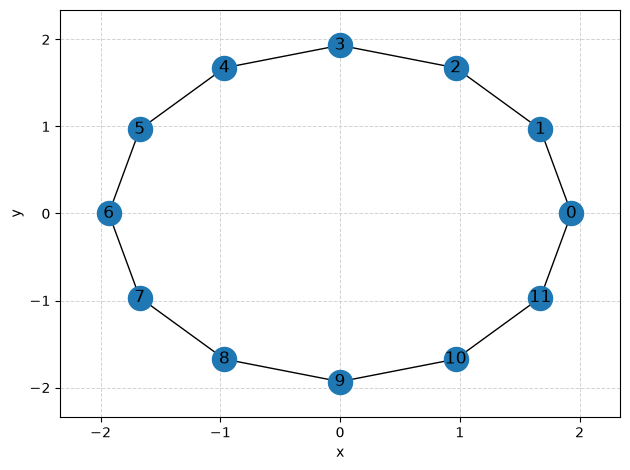

In [75]:
graph.draw()

Taking $\Omega_R = J_{nn}/2$, the derived Hamiltonian becomes

$$
H \;=\; \frac{J_{nn}}{4}\sum_i \sigma^z_i\sigma^z_{i+1} \;+\; \frac{\Omega_R}{2}\sum_j \sigma^x_j \;=\; \frac{1}{4}\,H_{\text{TFIM}}
$$

at the critical point $h=J=1$. A global rescaling of the Hamiltonian does not change the structure of the spectrum (nor the eigenstates), so this is exactly the critical state we are after.

The mapping from TFIM parameters to Rydberg drive parameters is then:

- **Rabi frequency:** $\Omega(t)\equiv\Omega_R=J_{nn}/2=1/2$, which sets the transverse field.
- **Detuning:** $\delta(t)$, chosen to compensate the residual local longitudinal field $h_i^z = \frac{1}{2}\sum_{j\neq i} J_{ij}$, so that the $\sigma^z_i$ term in the derived Hamiltonian vanishes and a pure transverse-field Ising model is left behind. We compute it directly from the `graph.interactions()` dictionary for any qubit; thanks to the ring's translational symmetry it is the same for every qubit. The physical detuning is then this constant offset: $\delta(t)=\Delta$.

In [76]:
# TFIM transverse field; the critical point sits at h = J = 1
h = 1.0

# Mapping to Rydberg parameters
J_nn = graph.interactions()[(0, 1)]   # nearest-neighbour coupling, = 1 at unit spacing
OMEGA_R = J_nn / 2                    # = 1/2 at the critical point

# Residual local detuning due to interactions with neighbors
hz = np.zeros(N)
for i in range(N):
    hz[i] = 0.5 * sum(
        graph.interactions()[(min(i, j), max(i, j))]
        for j in range(N) if j != i
    )
print(f"Local detuning due to interactions: {hz}")

DELTA = hz[0]

register = Register.from_graph(graph)
device = AnalogDevice()

print(f"N = {N} atoms on a ring")
print(f"J_nn = {J_nn:.4f}   Omega = {OMEGA_R:.4f}   delta = {DELTA:.4f}")

Local detuning due to interactions: [1.02287553 1.02287553 1.02287553 1.02287553 1.02287553 1.02287553
 1.02287553 1.02287553 1.02287553 1.02287553 1.02287553 1.02287553]
N = 12 atoms on a ring
J_nn = 1.0000   Omega = 0.5000   delta = 1.0229


## 3. Designing the quasi-adiabatic schedule

The adiabatic theorem says that if we tune a Hamiltonian slowly enough, a system prepared in the ground state stays in the ground state throughout the sweep. *"Slowly enough"* means slow compared to the inverse square of the energy gap between the ground and first excited state. 

Near a quantum critical point this gap closes, so a simple **linear** sweep is either wastefully slow everywhere, or not slow enough exactly where the gap is smallest. In our setting, it is right where we care about it: at the critical point at the end of the sweep.

To fix this, we use a **tangent sweep**: the detuning is swept from a large negative value $\delta_0 = -5\,\Omega_R$ up to the target $\delta$ following a $\tan$-shaped profile in time. This naturally slows the sweep down near the critical gap, where the system is most sensitive, and speeds it up everywhere else.

We start at $\delta_0 \ll 0$ which is the ground state of the drive Hamiltonian, the product state $|00\dots0\rangle$ (all atoms in the ground state $|gg\dots g\rangle$). This is easy to prepare exactly, giving us a clean, known starting point for the adiabatic sweep.


> **The full schedule has two phases**:
> 1. **Ramp-up** (first `frac_ramp` of the total time `T`): the Rabi frequency $\Omega(t)$ is smoothly turned on from $0$ to $\Omega_R$, while the detuning stays fixed at $\delta_0$ — this avoids a sudden jump in $\Omega$, which would itself break adiabaticity.
> 2. **Detuning sweep** (remaining time `T*(1-frac_ramp)`): $\Omega(t)=\Omega_R$ is held constant, and the detuning follows the tangent profile from $\delta_0$ toward $\Delta$, slowing down as it crosses the critical point.

In [77]:
def tangent_sweep(start, target, alpha, n_points):
    """
    Time-warped sweep from `start` to `target` using a tangent map.

    Instead of moving linearly in the normalized fraction s in [0, 1], we
    reparametrize so the sweep slows down near s=1 (the target) — exactly
    where the many-body energy gap is smallest, near the critical point.

    Args:
        start (float): Starting value of the sweep (e.g. the initial detuning d0).
        target (float): Target value the sweep converges to (e.g. DELTA).
        alpha (float): Curvature parameter of the tangent map; larger
            values slow the sweep down more sharply as it approaches
            `target`.
        n_points (int): Number of points used to sample the sweep.

    Returns:
        tuple[np.ndarray, np.ndarray]:
            s (np.ndarray): The normalized fraction along the sweep,
                linearly spaced in [0, 1], with length `n_points`.
            profile (np.ndarray): The corresponding swept values from
                `start` to `target`, following the tangent map, with the
                last point set exactly to `target`.
    """
    s = np.linspace(0.0, 1.0, n_points)
    tan_alpha = np.tan(alpha)
    profile = start + (target - start) * (1.0 - np.tan(alpha * (1.0 - s)) / tan_alpha)
    profile[-1] = target  # avoid floating-point drift; land exactly on target
    return s, profile

def build_program(T, frac_ramp=0.1, alpha=1.4, n_ctrl=81):
    """
    Build the quasi-adiabatic pulse sequence.

    Phase 1 (ramp-up, first `frac_ramp` of T): Omega turns on smoothly from
    0 to OMEGA_R, while the detuning stays fixed at d0 = -5 * OMEGA_R.

    Phase 2 (sweep, remaining time): Omega stays at OMEGA_R, while the
    detuning follows a tangent profile from d0 up to DELTA, slowing down
    as it crosses the critical point.

    Args:
        T (float): Total duration of the pulse sequence.
        frac_ramp (float): Fraction of T spent on the Omega ramp-up phase
            before the detuning sweep begins. Defaults to 0.1.
        alpha (float): Curvature parameter of the tangent sweep; larger
            values slow the sweep down more sharply near the target
            detuning DELTA. Defaults to 1.4.
        n_ctrl (int): Number of control points used to sample the tangent
            sweep during the detuning phase. Defaults to 81.

    Returns:
        QuantumProgram: A program on `register` with an amplitude (Rabi
            frequency) drive that ramps up to OMEGA_R, and a detuning drive
            that holds at d0 then sweeps to DELTA following the tangent
            profile.
    """
    d0 = -5.0 * OMEGA_R  # initial detuning, deep in the far-detuned regime

    # --- Phase 1: Rabi frequency ramp-up --- 
    # from t=0 to t=frac_ramp*T, ramp Omega from 0 to OMEGA_R
    # from t=frac_ramp*T to t=T, hold Omega at OMEGA_R
    omega_times = [0.0, frac_ramp, 1.0]
    omega_values = [0.0, OMEGA_R, OMEGA_R]

    # --- Phase 2: detuning sweep ---
    # Hold at d0 during the ramp-up phase...
    # from t=0 to t=frac_ramp*T, hold detuning at d0
    detuning_times = [0.0, frac_ramp]
    detuning_values = [d0, d0]

    # ...then follow the tangent profile from d0 to DELTA over the rest of the schedule
    # from t=frac_ramp*T to t=T, sweep detuning from d0 to DELTA
    # s is the normalized fraction along the sweep, linearly spaced in [0, 1]
    s, detuning_sweep = tangent_sweep(d0, DELTA, alpha, n_ctrl)
    sweep_times = frac_ramp + s * (1.0 - frac_ramp)

    detuning_times += sweep_times[1:].tolist()
    detuning_values += detuning_sweep[1:].tolist()

    return QuantumProgram(register, Drive(
        amplitude=InterpolatedWaveform(T, values=omega_values, times=omega_times),
        detuning=InterpolatedWaveform(T, values=detuning_values, times=detuning_times),
    ))

Before running anything, let's *see* the schedule. For a representative dimensionless time $\tilde{t} = 80$, `program.draw()` shows the two dimensionless control fields:

- the Rabi amplitude $\Omega(\tilde{t})$ — a quick ramp, then held at $\Omega_R$;
- the detuning $\delta(\tilde{t})$ — held at $\delta_0$ during the ramp, then swept up to $\Delta$.

Notice how the detuning **flattens as it approaches the target**: that is the tangent slowdown, spending proportionally more evolution time near the end of the sweep, where the many-body gap is smallest.

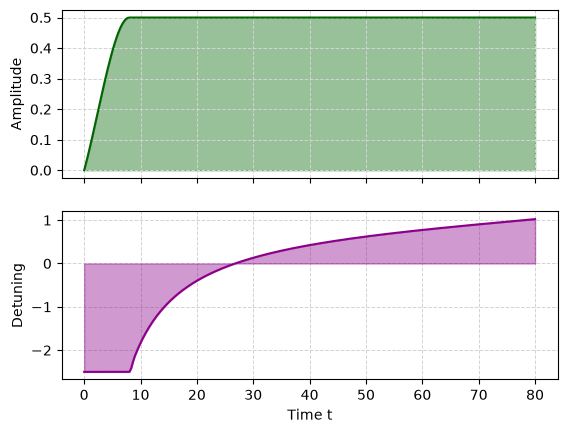

In [78]:
demo = build_program(80.0)
demo.draw()

Everything above is defined in **dimensionless units**; `compile_to` maps the program onto the device's physical scale. 


It is worth inspecting the actual physical amplitude and detuning versus time in ns, that the backend will run. This is what the hardware sees for one representative $\tilde{t}$:

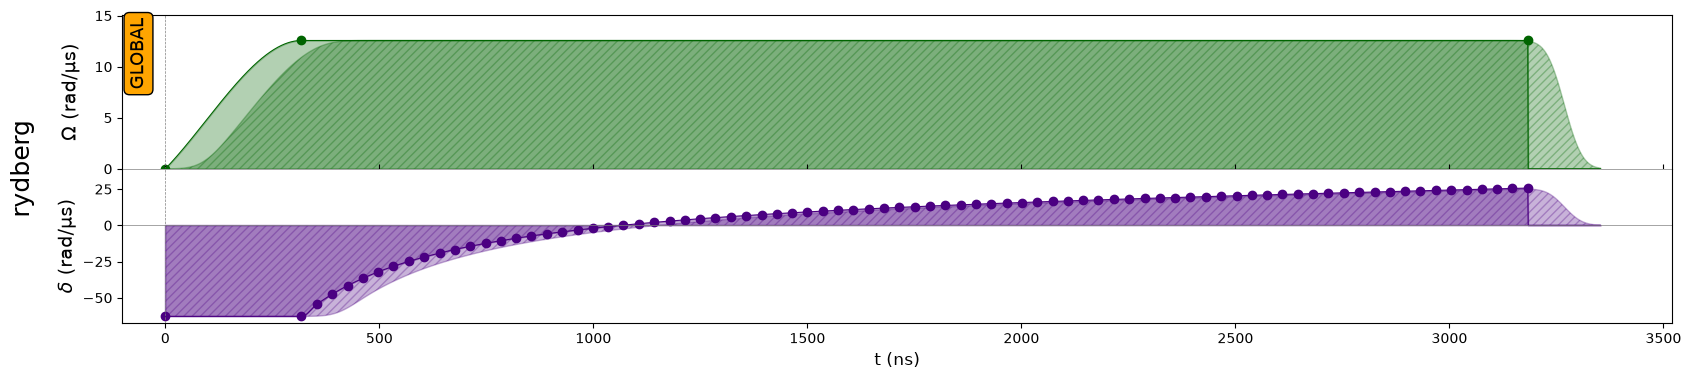

In [79]:
demo = build_program(80.0)
demo.compile_to(device)
demo.draw(compiled=True)

## 4. Computing the target state with exact diagonalization

Before running the adiabatic preparation, we need a reference ground state to compare against. Since $N = 12$ is still small enough, we can build the full Rydberg Hamiltonian at the endpoint parameters $(\Omega, \delta)$ and diagonalize it exactly.

The Rydberg Hamiltonian we diagonalize is

$$
H(\Omega, \delta) = \frac{\Omega}{2}\sum_j \sigma^x_j - \delta \sum_j n_j + \sum_{i<j} J_{ij}\, n_i n_j
$$



In [ ]:
from functools import reduce

from scipy.sparse import csr_matrix, identity, kron
from scipy.sparse.linalg import eigsh

I2 = identity(2, format="csr")
SIGMA_X = csr_matrix(np.array([[0, 1.], [1., 0]]))
SIGMA_Z = csr_matrix(np.array([[1., 0], [0, -1.]]))
N_OP    = csr_matrix(np.diag([0.0, 1.0]))

def local_operator(op, site, N):
    """
    Embed a single-site operator `op` acting on `site` into the full
    2^N-dimensional Hilbert space.
    Args:
        op (scipy.sparse matrix): 2x2 single-site operator.
        site (int): Index of the site `op` acts on, in [0, N).
        N (int): Total number of sites.

    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) embedded operator.
    """
    ops = [I2] * N
    ops[site] = op
    return reduce(lambda a, b: kron(a, b, format="csr"), ops)  # kron(I2, ..., op, ..., I2)

def build_target_hamiltonian(N, graph, omega, delta):
    """
    Build the sparse 2^N x 2^N Rydberg Hamiltonian:
        H = sum_j [ (omega/2) sigma^x_j - delta n_j ] + sum_{i<j} J_ij n_i n_j
    using Kronecker products of local operators.
    Args:
        N (int): Number of atoms/sites.
        graph: The register/graph object, providing `graph.interactions()`
            as a dict mapping (i, j) with i < j to J_ij.
        omega (float): Rabi frequency driving sigma^x on every site.
        delta (float): Detuning driving -n_i on every site.
    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) Hamiltonian.
    """
    dim = 2 ** N

    n_ops = [local_operator(N_OP, j, N) for j in range(N)]
    x_ops = [local_operator(SIGMA_X, j, N) for j in range(N)]

    # Drive terms: (omega/2) sigma^x_j - delta n_j, summed over all sites.
    H = csr_matrix((dim, dim))
    for j in range(N):
        H = H + 0.5 * omega * x_ops[j] - delta * n_ops[j]

    # Interaction terms: J_ij n_i n_j, summed over all pairs i < j, read
    # directly from the graph's interactions dict.
    for (i, j), val in graph.interactions().items():
        H = H + val * (n_ops[i] @ n_ops[j])
    return H.tocsr()

# Diagonalize the target Hamiltonian (only the two lowest eigenpairs are needed)
# We use the value of DELTA and OMEGA_R that correspond to the critical point of the TFIM,
# The ground state of H_target is the critical state we want to prepare.
H_target = build_target_hamiltonian(N, graph, OMEGA_R, DELTA)
evals, evecs = eigsh(H_target, k=2, which="SA")
order = np.argsort(evals)
evals, evecs = evals[order], evecs[:, order]
psi_gs = evecs[:, 0]
print(f"E_0 = {evals[0]:.6f},  E_1 = {evals[1]:.6f},  gap = {evals[1] - evals[0]:.6f}")

E_0 = -6.871569,  E_1 = -6.832049,  gap = 0.039520


**Why a tangent sweep?** The adiabatic cost is governed by the *instantaneous* gap along the path we follow. Keeping $\Omega=\Omega_R$ fixed and sweeping the detuning from $\delta_0$ to $\Delta$, we can diagonalize $H(\Omega_R,\delta)$ at each step and track the gap directly. It is large at the start (deep in the far-detuned regime, where the ground state is the trivial product state) and **shrinks as we approach the critical endpoint**:  which is precisely where the tangent schedule slows down. 

In the plot below we overlay the gap (left axis) and the detuning pulse $\delta$ itself (right axis) against the sweep progress $s\propto t$. The pulse **flattens**, i.e. where the sweep spends more time, is exactly in the shaded region where the gap is smallest.

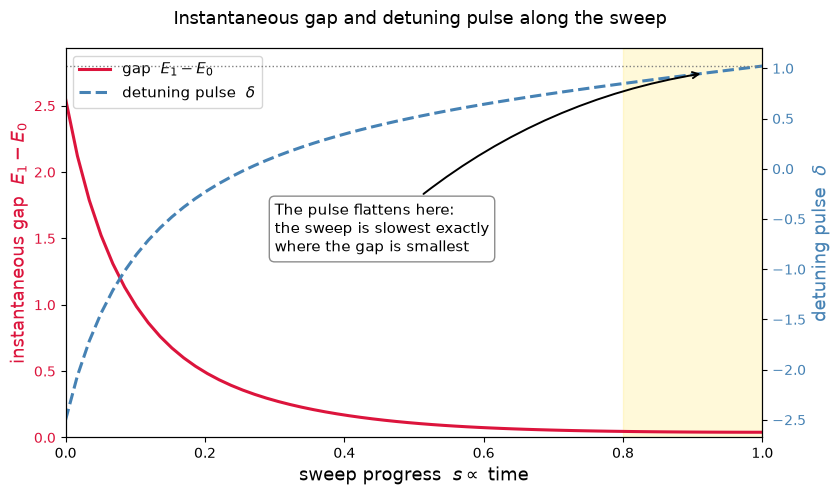

In [ ]:
# Track the gap along the tangent detuning sweep (same alpha as build_program),
# and overlay the detuning pulse itself. Plotting both against the sweep progress s
alpha = 1.4                                     
d0 = -5.0 * OMEGA_R
s, delta_pulse = tangent_sweep(d0, DELTA, alpha, 60)   # s in [0, 1] is proportional to time

# Precompute the delta-independent part of H and the operator sum_j n_j once for speed.
n_ops = [local_operator(N_OP, j, N) for j in range(N)]
sum_n = n_ops[0]
for op in n_ops[1:]:
    sum_n = sum_n + op
H_base = build_target_hamiltonian(N, graph, OMEGA_R, 0.0)

gaps = np.array([
    np.diff(np.sort(eigsh(H_base - de * sum_n, k=2, which="SA")[0]))[0]
    for de in delta_pulse
])

fig, ax1 = plt.subplots(figsize=(8.5, 5))

# highlight the slow / small-gap region at the end of the sweep
ax1.axvspan(0.8, 1.0, color="gold", alpha=0.15)

# left axis: instantaneous gap
gap_color = "crimson"
ax1.plot(s, gaps, color=gap_color, lw=2.2)
ax1.set_xlabel(r"sweep progress  $s \propto$ time", size=13)
ax1.set_ylabel(r"instantaneous gap  $E_1 - E_0$", size=13, color=gap_color)
ax1.tick_params(axis="y", labelcolor=gap_color)
ax1.set_ylim(0, gaps.max() * 1.15)
ax1.set_xlim(0, 1)

# right axis: the detuning pulse delta(t)
ax2 = ax1.twinx()
pulse_color = "steelblue"
ax2.plot(s, delta_pulse, color=pulse_color, lw=2.2, ls="--")
ax2.axhline(DELTA, ls=":", color="gray", lw=1)
ax2.set_ylabel(r"detuning pulse  $\delta$", size=13, color=pulse_color)
ax2.tick_params(axis="y", labelcolor=pulse_color)

# annotation: the pulse flattens (slow sweep) right where the gap is small
i_tail = int(0.92 * (len(s) - 1))
ax2.annotate(
    "The pulse flattens here:\nthe sweep is slowest exactly\nwhere the gap is smallest",
    xy=(s[i_tail], delta_pulse[i_tail]), xycoords="data",
    xytext=(0.30, -0.6), textcoords="data",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.4,
                    connectionstyle="arc3,rad=-0.15"),
    fontsize=11, ha="left", va="center",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.9),
)

from matplotlib.lines import Line2D

handles = [Line2D([0], [0], color=gap_color, lw=2.2, label=r"gap  $E_1 - E_0$"),
           Line2D([0], [0], color=pulse_color, lw=2.2, ls="--", label=r"detuning pulse  $\delta$")]
ax1.legend(handles=handles, loc="upper left", fontsize=11)

fig.suptitle("Instantaneous gap and detuning pulse along the sweep", size=13)
fig.tight_layout()
plt.show()

### How close is the Rydberg target to the *ideal* TFIM critical state?

The state we prepare is the ground state of the **Rydberg** Hamiltonian at the endpoint parameters — not, exactly, the ground state of the clean nearest-neighbor TFIM. It is worth quantifying the difference once, as a sanity check on the mapping.

We build the ideal periodic TFIM on the same ring,

$$
H_{\text{TFIM}} = \sum_i \sigma^z_i\sigma^z_{i+1} + h\sum_i \sigma^x_i, \qquad \sigma^z_{N+1}\equiv\sigma^z_1,
$$

and compute the overlap of its ground state with our Rydberg target. For our periodic ring the two are remarkably close: the overlap comes out around $0.997$. The tiny residual gap below $1$ is the price of realizing an idealized spin model on real Rydberg hardware, the Rydberg Hamiltonian carries long-range interaction tails beyond nearest neighbors and a residual local field.

In [ ]:
def build_TFIM_hamiltonian(N, h):
    """
    Build the sparse 2^N x 2^N periodic transverse-field Ising Hamiltonian:
        H = sum_{i=0}^{N-1} sigma^z_i sigma^z_{i+1} + h sum_{i=0}^{N-1} sigma^x_i

    The z-z sum closes the ring (site N is identified with site 0), matching
    the periodic geometry of the Rydberg register.

    Args:
        N (int): Number of spins.
        h (float): Transverse field strength.

    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) Hamiltonian.
    """
    dim = 2 ** N
    z_ops = [local_operator(SIGMA_Z, j, N) for j in range(N)]
    x_ops = [local_operator(SIGMA_X, j, N) for j in range(N)]

    H = csr_matrix((dim, dim))
    # Interaction terms on the ring: sum_i sigma^z_i sigma^z_{i+1}, with pbc
    for i in range(N):
        H = H + z_ops[i] @ z_ops[(i + 1) % N]
    # Transverse field terms: h sum_i sigma^x_i
    for j in range(N):
        H = H + h * x_ops[j]
    return H.tocsr()

# Ground state of the ideal periodic TFIM, and its overlap with the Rydberg target.
H_TFIM = build_TFIM_hamiltonian(N, h)
evals_tfim, evecs_tfim = eigsh(H_TFIM, k=1, which="SA")
psi_TFIM_gs = evecs_tfim[:, 0]

overlap_tfim = np.abs(np.vdot(psi_TFIM_gs, psi_gs)) ** 2
print(f"Overlap between ideal TFIM ground state and Rydberg target: {overlap_tfim:.4f}")

Overlap between ideal TFIM ground state and Rydberg target: 0.9969


From the ED ground state we can directly compute the target occupation $\langle n_i \rangle$ and the correlation matrix $\langle n_i n_j \rangle$ for later comparison.


In [ ]:
def occupation_and_corr_from_psi(psi):
    """
    Compute <n_i> and <n_i n_j> from a dense state vector. 
    """
    n_ops = [local_operator(N_OP, j, N) for j in range(N)]
    occ_per_state = np.stack([op.diagonal() for op in n_ops], axis=1)  # (dim, N)
    p = np.abs(psi) ** 2
    occ = occ_per_state.T @ p
    corr = np.einsum("ki,kj,k->ij", occ_per_state, occ_per_state, p)
    return occ.real, corr.real


occ_t, corr_t = occupation_and_corr_from_psi(psi_gs)
conn_t = corr_t - np.outer(occ_t, occ_t)  # Connected correlations

print(f"Target <n> = {np.mean(occ_t):.4f}")

Target <n> = 0.5000


## 5. Running the adiabatic state preparation

We now run the actual time-evolution under the quasi-adiabatic schedule using the **`emu_sv`** backend (exact state-vector propagation).

**A note on time.** qoolqit programs live in *dimensionless* units: the drive duration $\tilde{t}$ is measured relative to the timescale on which the interactions build up correlations, so $\tilde{t} \sim 1$ is "one interaction time" and $\tilde{t} \gg 1$ is a slow, near-adiabatic evolution. This is the natural knob for the adiabatic theorem: the slower the sweep compared to the interaction timescale, the better we track the instantaneous ground state through the small gap. 

We sweep the dimensionless total time $\tilde{t}$ directly, letting the compiler map each value onto the device; **no hardware duration needs to be specified by hand**. 

For each $\tilde{t}$ we request three observables: (i) the occupation $\langle n_i\rangle$, (ii) the correlation matrix $\langle n_i n_j\rangle$, and (iii) the fidelity against the ED ground state. 

In [84]:
# Convert the ED ground state to an emu_sv StateVector for the Fidelity observable
n_ops = [local_operator(N_OP, j, N) for j in range(N)]

# Each n_op is diagonal with real 0/1 entries; take the real part before casting to int.
occ_per_state = np.stack([op.diagonal().real for op in n_ops], axis=1).astype(int)  # (dim, N)
GR = np.array(["g", "r"])
labels = ["".join(row) for row in GR[occ_per_state]]

amplitudes = dict(zip(labels, psi_gs.astype(float)))
target_state = StateVector.from_state_amplitudes(
    eigenstates=("g", "r"), amplitudes=amplitudes
)

In [91]:
# Configure observables: occupation, correlation matrix, and fidelity vs. the ED target.
config = EmulationConfig(
    observables=(
        Occupation(evaluation_times=[1.0]),
        CorrelationMatrix(evaluation_times=[1.0]),
        Fidelity(evaluation_times=[1.0], state=target_state),
    ),
    log_level=logging.WARN
)

# Sweep the dimensionless total evolution time. Larger t~ => slower, more adiabatic sweep.
t_sweep = np.linspace(10.0, 120.0, 11)
fid_vs_t = np.zeros(len(t_sweep))

for i, t in enumerate(t_sweep):
    # Build the program at dimensionless duration t and compile it to the device.
    prog = build_program(t)
    prog.compile_to(device)

    # Run the adiabatic evolution
    emulator = LocalEmulator(backend_type=SVBackend, emulation_config=config)
    job = emulator.run(prog)
    tagged = job.results().get_tagged_results()

    # Fidelity with the ED target, straight from the emu_sv Fidelity observable.
    fid_vs_t[i] = float(np.asarray(tagged["fidelity"][-1]).real)

# Occupation and correlations from the final (largest-t~, most adiabatic) run.
occ_p  = np.asarray(tagged["occupation"][-1]).real
corr_p = np.asarray(tagged["correlation_matrix"][-1]).real
conn_p = corr_p - np.outer(occ_p, occ_p)
fid    = fid_vs_t[-1]

### Comparison plots

We now compare the prepared state against the ED target across several observables. The density, correlation, and staggered-correlation panels use the **final, largest-$\tilde{t}$ run** (the slowest, most adiabatic sweep), while the fidelity panel shows the full dependence on $\tilde{t}$:

> 1. **Infidelity**: checks the overlap with the exact ground state, as a function of the dimensionless evolution time $\tilde{t}$.
> 2. **Rydberg density** $\langle n_i \rangle$: at the critical point, this should be close to $1/2$ for all sites.
> 3. **Connected correlations** $C_{\text{conn}}(d) = \langle n_i n_{i+d}\rangle - \langle n_i\rangle\langle n_{i+d}\rangle$: these should decay algebraically at criticality.
> 4. **Staggered correlations** $(-1)^d C_{\text{conn}}(d)$: reveal antiferromagnetic ordering tendencies.

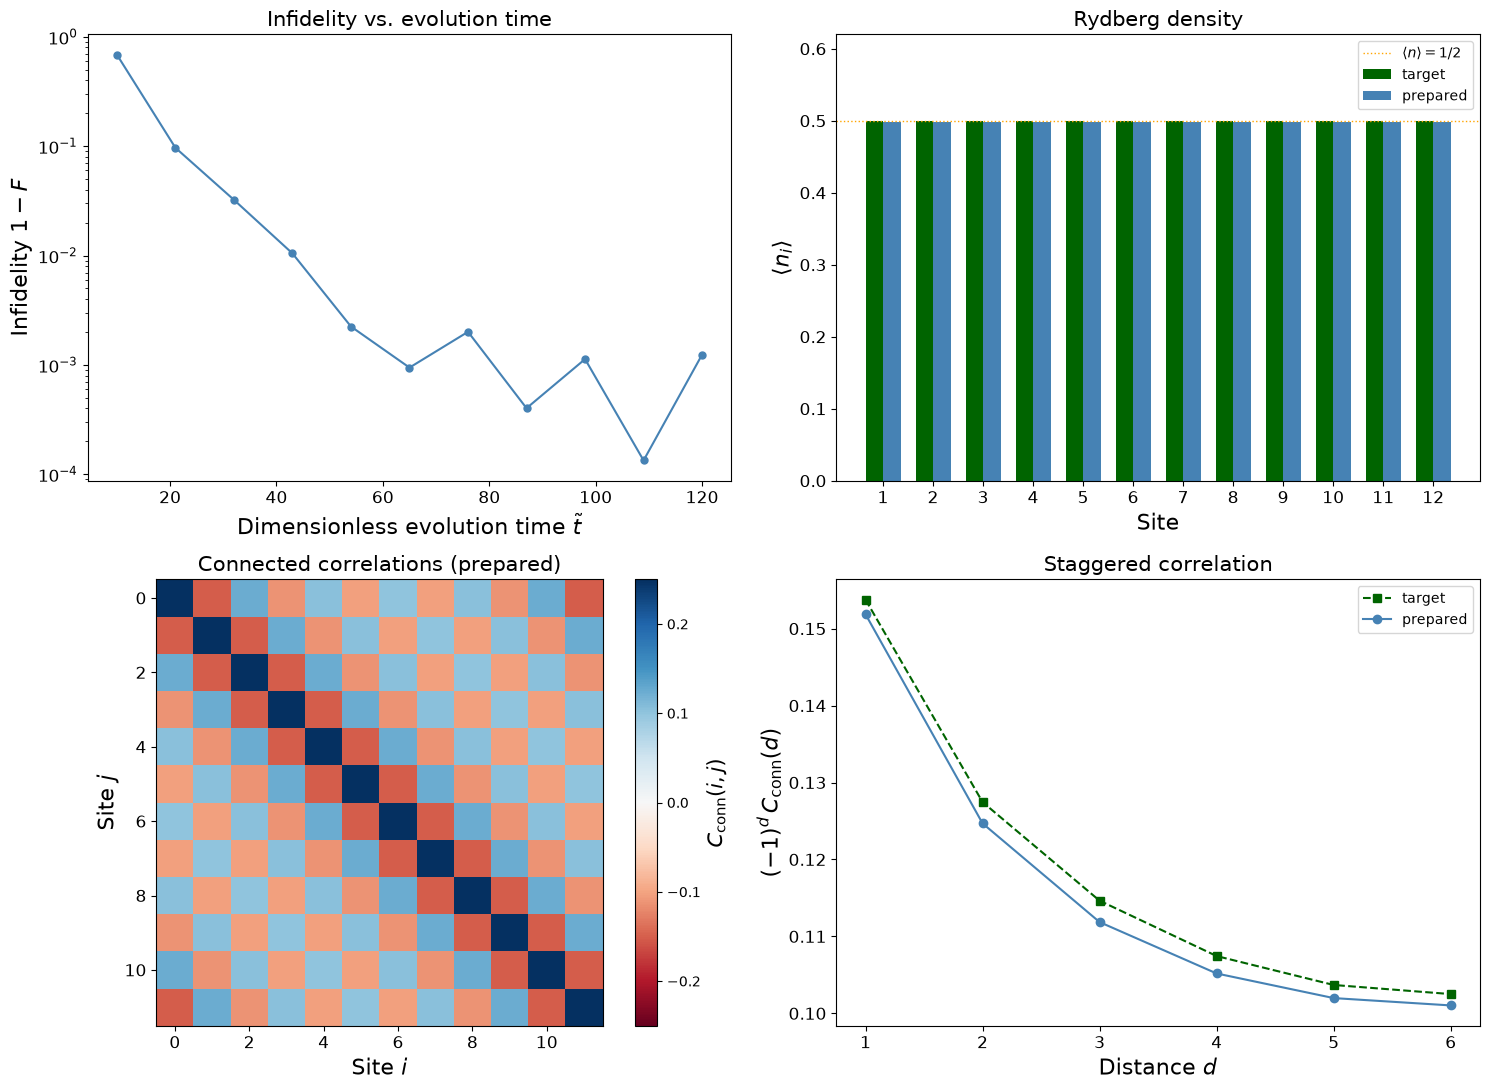

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Infidelity vs. dimensionless evolution time (the headline result) ---
ax = axes[0, 0]
ax.semilogy(t_sweep, 1 - fid_vs_t, "o-", color="steelblue", ms=5)
ax.set_xlabel(r"Dimensionless evolution time $\tilde{t}$", size=16)
ax.set_ylabel("Infidelity $1-F$", size=16)
ax.set_title("Infidelity vs. evolution time", size=15)

# --- Rydberg density: ~1/2 on every site at the symmetric critical point ---
ax = axes[0, 1]
x = np.arange(N)
w = 0.35
ax.bar(x - w/2, occ_t, w, color="darkgreen", label="target")
ax.bar(x + w/2, occ_p, w, color="steelblue", label="prepared")
ax.axhline(0.5, color="orange", ls=":", lw=1, label=r"$\langle n\rangle=1/2$")
ax.set_xlabel("Site", size=16)
ax.set_ylabel(r"$\langle n_i \rangle$", size=16)
ax.set_xticks(x, x + 1)
ax.set_ylim(0, 0.62)
ax.set_title("Rydberg density", size=15)
ax.legend()

# --- Connected-correlation structure of the prepared state ---
ax = axes[1, 0]
im = ax.imshow(conn_p, cmap="RdBu", vmin=-0.25, vmax=0.25)
ax.set_xlabel("Site $i$", size=16)
ax.set_ylabel("Site $j$", size=16)
ax.set_title("Connected correlations (prepared)", size=15)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$C_{\mathrm{conn}}(i,j)$", size=15)

# --- Staggered correlation vs distance: prepared reproduces the ED target ---
ax = axes[1, 1]
max_d = N // 2
dists = np.arange(1, max_d + 1)
stag_t = np.array([(-1)**d * np.mean([conn_t[i, (i+d) % N] for i in range(N)]) for d in dists])
stag_p = np.array([(-1)**d * np.mean([conn_p[i, (i+d) % N] for i in range(N)]) for d in dists])
ax.plot(dists, stag_t, "s--", color="darkgreen", ms=6, label="target")
ax.plot(dists, stag_p, "o-",  color="steelblue", ms=6, label="prepared")
ax.set_xlabel("Distance $d$", size=16)
ax.set_ylabel(r"$(-1)^d\,C_{\mathrm{conn}}(d)$", size=16)
ax.set_xticks(dists)
ax.set_title("Staggered correlation", size=15)
ax.legend()

for a in axes.flat:
    a.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

## 6. Conclusion

We prepared the critical ground state of the 1D Transverse-Field Ising Model on a ring of 12 atoms using a quasi-adiabatic tangent sweep in **qoolqit**'s Rydberg analog model. Sweeping the *dimensionless* evolution time $\tilde{t}$, the fidelity with the ED target rises toward $1$ as the sweep becomes slower and saturates once $\tilde{t}$ is comfortably larger than the interaction timescale, even across the small critical gap.